# Preprocess data

In [2]:
# train_no_augment.ipynb

# Libraries
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import librosa
import soundfile as sf
import glob
from collections import Counter
import random
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LSTM, TimeDistributed
from tensorflow.keras.layers import Reshape, BatchNormalization
import numpy as np
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import shutil # Để xóa output kaggle


2025-07-07 14:14:31.972613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751897672.257894      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751897672.336148      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## 1. CREMA_D

In [3]:
Crema = "/kaggle/input/dataset-ser/Data/CREMA_D/"
Ravdess = "/kaggle/input/dataset-ser/Data/RAVDESS/"
Savee = "/kaggle/input/dataset-ser/Data/SAVEE/"
Tess = "/kaggle/input/dataset-ser/Data/TESS/"


file_emotion = []
file_path = []

# Duyệt qua từng file trong thư mục CREMA_D
for file in os.listdir(Crema):
    if file.endswith(".wav"):
        part = file.split('_')  # VD: 1001_DFA_ANG_XX.wav
        emotion = part[2]       # "ANG"
        file_emotion.append(emotion.lower())  # chuyển về chữ thường: "ang"
        file_path.append(Crema + file)

# Tạo DataFrame
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)

Crema_df.head()


Crema_df['Emotions'].value_counts()

Emotions
dis    1271
hap    1271
sad    1271
fea    1271
ang    1271
neu    1087
Name: count, dtype: int64

## 2. Ravdess

In [4]:
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    # Có 24 diễn viên
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        # Phần tử thứ 3 là cảm xúc
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

# changing integers to actual emotions.
Ravdess_df['Emotions'] = Ravdess_df['Emotions'].replace({
    1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
    5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'
})
Ravdess_df.head()

,Emotions,Path
0,surprise,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
1,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
2,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
3,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
4,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...


## 3. SAVEE

In [5]:
savee_directory_list = os.listdir(Savee)

file_emotion = []
file_path = []

for file in savee_directory_list:
    file_path.append(Savee + file)
    part = file.split('_')[1]
    ele = part[:-6]
    if ele=='a':
        file_emotion.append('angry')
    elif ele=='d':
        file_emotion.append('disgust')
    elif ele=='f':
        file_emotion.append('fear')
    elif ele=='h':
        file_emotion.append('happy')
    elif ele=='n':
        file_emotion.append('neutral')
    elif ele=='sa':
        file_emotion.append('sad')
    else:
        file_emotion.append('surprise')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Savee_df = pd.concat([emotion_df, path_df], axis=1)
Savee_df.head()

,Emotions,Path
0,happy,/kaggle/input/dataset-ser/Data/SAVEE/JE_h09.wav
1,fear,/kaggle/input/dataset-ser/Data/SAVEE/KL_f12.wav
2,happy,/kaggle/input/dataset-ser/Data/SAVEE/DC_h03.wav
3,disgust,/kaggle/input/dataset-ser/Data/SAVEE/DC_d04.wav
4,angry,/kaggle/input/dataset-ser/Data/SAVEE/KL_a14.wav


## 4. TESS

In [6]:
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()

,Emotions,Path
0,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
1,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
2,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
3,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...
4,fear,/kaggle/input/dataset-ser/Data/TESS/YAF_fear/Y...


In [7]:
# creating Dataframe using all the 4 dataframes we created so far.
data_path = pd.concat([Ravdess_df, Crema_df, Tess_df, Savee_df], axis = 0)
data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,surprise,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
1,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
2,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
3,disgust,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...
4,neutral,/kaggle/input/dataset-ser/Data/RAVDESS/Actor_0...


In [8]:
print ("Total examples: ",data_path['Emotions'].value_counts().sum())
print(data_path['Emotions'].value_counts())


Total examples:  12162
Emotions
sad         1923
dis         1271
hap         1271
fea         1271
ang         1271
neu         1087
surprise     652
disgust      652
fear         652
happy        652
angry        652
neutral      616
calm         192
Name: count, dtype: int64


In [9]:
data_path['Emotions'] = data_path['Emotions'].replace({
    'hap': 'happy',
    'fea': 'fear',
    'dis': 'disgust',
    'ang': 'angry',
    'neu': 'neutral'
})

# Process

## Split train - dev - test

In [10]:
# 1. Load dataframe gốc (không augment)
# Chia train,dev,test
# Đảm bảo phân phối cảm xúc được giữ đều (stratify)
train_df, temp_df = train_test_split( data_path, test_size=0.3, stratify=data_path['Emotions'], random_state=42)
# temp_df = test + dev = 30 % data
dev_df, test_df = train_test_split(temp_df, test_size=0.5,stratify=temp_df['Emotions'], random_state=42)


## Extract MFCC

In [11]:
# 2. MFCC extractor
def extract_mfcc(file_path, n_mfcc=40, max_pad_len=862):
    audio, sr = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
    if mfcc.shape[1] < max_pad_len:
        pad_width = max_pad_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_pad_len]
    return mfcc

In [12]:
# 3. Load MFCC features
def load_mfcc_from_df(df, le=None):
    X, y = [], []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        mfcc = extract_mfcc(row['Path'])
        if mfcc is not None:
            X.append(mfcc)
            y.append(row['Emotions'])
    X = np.array(X)[..., np.newaxis]
    if le is None:
        le = LabelEncoder()
        y_encoded = le.fit_transform(y)
    else:
        y_encoded = le.transform(y)
    y_encoded = to_categorical(y_encoded)
    return X, y_encoded, le

X_train, y_train, le = load_mfcc_from_df(train_df)
X_val, y_val, _ = load_mfcc_from_df(dev_df, le)
X_test, y_test, _ = load_mfcc_from_df(test_df, le)

100%|██████████| 1825/1825 [00:42<00:00, 43.36it/s]


# Model

In [13]:
# 4. Build model (same architecture)
def build_model(input_shape=(40, 862, 1), num_classes=8, dropout_rate=0.3, units_lstm=128):
    inputs = Input(shape=input_shape)

    # CNN block 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(dropout_rate)(x)

    # CNN block 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(dropout_rate)(x)

    # Reshape để đưa vào LSTM
    x = Reshape((-1, x.shape[2] * x.shape[3]))(x)

    # LSTM
    x = LSTM(units_lstm, return_sequences=False)(x)
    x = Dropout(dropout_rate)(x)

    # Output
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [14]:
# 5. Compile + Train model
model = build_model(input_shape=(40, 862, 1), num_classes=y_train.shape[1])
model.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])

checkpoint = ModelCheckpoint("best_model.h5", monitor='val_accuracy', save_best_only=True)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-5,verbose=1)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[checkpoint, early_stop,reduce_lr],
    verbose=1
)



2025-07-07 08:46:51.023243: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 605s 2s/step - accuracy: 0.2616 - loss: 1.8588 - val_accuracy: 0.3832 - val_loss: 1.6003 - learning_rate: 0.0010
Epoch 2/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 596s 2s/step - accuracy: 0.3857 - loss: 1.5848 - val_accuracy: 0.4145 - val_loss: 1.5095 - learning_rate: 0.0010
Epoch 3/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 585s 2s/step - accuracy: 0.4141 - loss: 1.4831 - val_accuracy: 0.3947 - val_loss: 1.5244 - learning_rate: 0.0010
Epoch 4/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 580s 2s/step - accuracy: 0.4335 - loss: 1.4307 - val_accuracy: 0.4265 - val_loss: 1.4267 - learning_rate: 0.0010
Epoch 5/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 579s 2s/step - accuracy: 0.4748 - loss: 1.3198 - val_accuracy: 0.4391 - val_loss: 1.3883 - learning_rate: 0.0010
Epoch 6/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 583s 2s/step - accuracy: 0.4942 - loss: 1.2944 - val_accuracy: 0.4973 - val_loss: 1.2786 - learning_rate: 0.0010
Epoch 7/50
267/267 ━━━━━━━━━━━━━━━━━━━━ 581s 2s/step - accuracy: 0.5225 - loss: 1.

# Evaluate model

In [5]:
# 6. Đánh giá trên test
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Giả sử bạn đã có:
# y_true: ground truth (label thật)
# y_pred: dự đoán (dạng số nguyên, sau argmax nếu dùng softmax)

# Ví dụ: nếu dùng one-hot thì phải argmax:
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(model.predict(X_test), axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print("✅ Accuracy:", acc)

# F1, Precision, Recall
print("🔍 Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

NameError: name 'y_test' is not defined

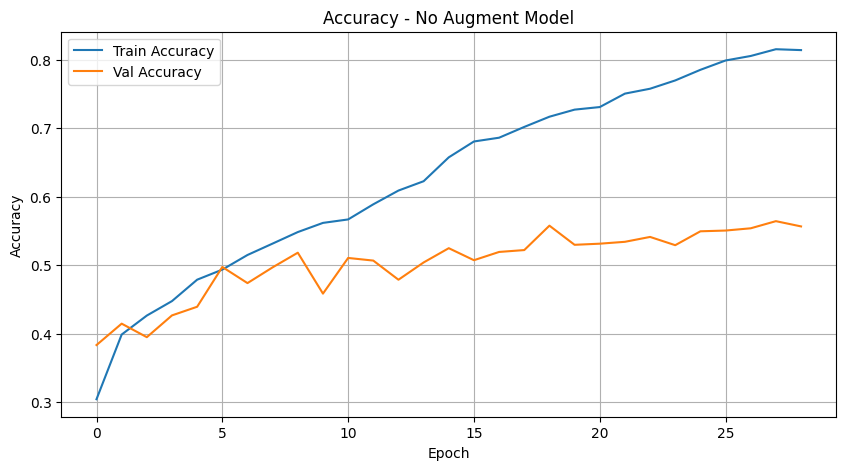

58/58 ━━━━━━━━━━━━━━━━━━━━ 21s 364ms/step


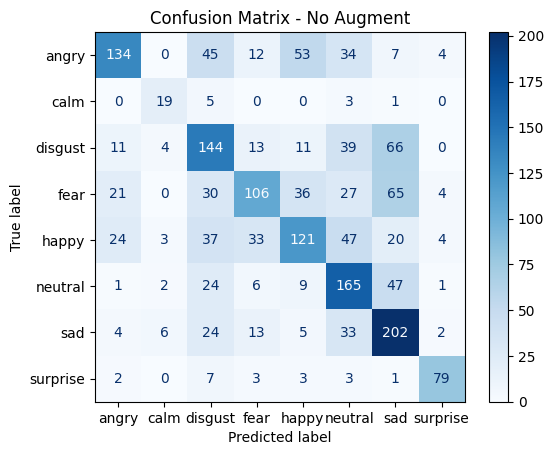

In [16]:
# 7. Vẽ Accuracy (train vs val)
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy - No Augment Model')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# 8. Confusion Matrix
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix - No Augment")
plt.show()